# DeepSeek + Logic Tensor Network Market Regime Experiment

Notebook pulls all data from Hugging Face, builds the date-bounded dataset, shows what the data looks like, trains a frozen DeepSeek baseline, trains a DeepSeek + LTN model using `LTNtorch`, and compares performance on bullish/bearish/sideways future market regimes.

The target is `future_price_trend_id`: `0=bear_drawdown`, `1=sideways`, `2=bull_rally`.

## Important modelling note

A Logic Tensor Network does **not** discover symbolic rules from nothing. In the usual LTN setup, you provide logical formulas such as `material & tightening -> bear_drawdown`, and the neural model learns parameters whose predictions satisfy those formulas as well as the supervised labels. The learnable part is the classifier/predicates, not the rule text itself.

So the LTN should be treated as a **regularised baseline comparison**, not as an automatic rule-mining system. If the rules are weak, contradicted by the data, or too heavily weighted, the LTN can easily hurt performance.

This version also avoids repeatedly recomputing frozen DeepSeek embeddings every epoch. DeepSeek is used as a fixed feature extractor, and text embeddings are cached across the baseline and LTN runs.


In [1]:
from pathlib import Path
import fnmatch, json, math, os, random
import getpass
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from huggingface_hub import HfApi, hf_hub_download

# 1. Securely prompt for your Hugging Face Token inside the notebook
print("Please paste your Hugging Face Read Token below:")
HF_TOKEN = getpass.getpass("HF Token: ")

NEWS_REPO = "cookekieran/alphavantage-market-news"
PRICES_REPO = "cookekieran/mag7_prices"
MACRO_REPO = "cookekieran/fred-macro-data"

WORK_DIR = Path("deepseek_ltn_work")
DATA_DIR = WORK_DIR / "data" / "processed"
MODEL_DIR = WORK_DIR / "models"
DATA_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

TICKERS = ["NVDA", "AAPL", "MSFT", "GOOGL", "AMZN", "META", "TSLA"]
TREND_WINDOW_DAYS = 120
TREND_THRESHOLD = 0.20
TREND_FORWARD_DAYS = 20
VALIDATION_START = "2025-04-01"
TEST_START = "2025-07-01"

# Increase these when the smoke test works and the container has enough GPU memory/time.
MAX_TRAIN_ROWS = None
MAX_VALIDATION_ROWS = None
MAX_TEST_ROWS = None
BATCH_SIZE = 64
EPOCHS = 8
MAX_LENGTH = 256
USE_BALANCED_BATCHES = True
LOGIC_WEIGHT = 0.05
MODEL_ID = "deepseek-ai/DeepSeek-R1-Distill-Llama-8B"

# 2. Pass your token to the HfApi client initialization
api = HfApi(token=HF_TOKEN)

for repo in [NEWS_REPO, PRICES_REPO, MACRO_REPO]:
    print()
    print(repo)
    # 3. Pass the token explicitly into list_repo_files as well
    for f in api.list_repo_files(repo, repo_type="dataset", token=HF_TOKEN)[:30]:
        print(" ", f)


Please paste your Hugging Face Read Token below:


HF Token:  ········



cookekieran/alphavantage-market-news
  .gitattributes
  README.md
  articles/2023-01.parquet
  articles/2023-02.parquet
  articles/2023-03.parquet
  articles/2023-04.parquet
  articles/2023-05.parquet
  articles/2023-06.parquet
  articles/2023-07.parquet
  articles/2023-08.parquet
  articles/2023-09.parquet
  articles/2023-10.parquet
  articles/2023-11.parquet
  articles/2023-12.parquet
  articles/2024-01.parquet
  articles/2024-02.parquet
  articles/2024-03.parquet
  articles/2024-04.parquet
  articles/2024-05.parquet
  articles/2024-06.parquet
  articles/2024-07.parquet
  articles/2024-08.parquet
  articles/2024-09.parquet
  articles/2024-10.parquet
  articles/2024-11.parquet
  articles/2024-12.parquet
  articles/2025-01.parquet
  articles/2025-02.parquet
  articles/2025-03.parquet
  articles/2025-04.parquet

cookekieran/mag7_prices
  .gitattributes
  README.md
  mag7_daily_prices.parquet

cookekieran/fred-macro-data
  .gitattributes
  README.md
  fred_macro_raw.csv
  fred_macro_raw

In [2]:
def read_hf_parquets(repo_id, pattern, token=None):
    # Pass token to list_repo_files
    files = sorted(f for f in api.list_repo_files(repo_id, repo_type="dataset", token=token) if fnmatch.fnmatch(f, pattern))
    if not files:
        raise FileNotFoundError(f"No files matched {pattern!r} in {repo_id}")
    frames = []
    for f in files:
        # Pass token to hf_hub_download
        path = hf_hub_download(repo_id=repo_id, repo_type="dataset", filename=f, token=token)
        df = pd.read_parquet(path)
        df["source_file"] = f
        frames.append(df)
    return pd.concat(frames, ignore_index=True)

def read_hf_parquet(repo_id, preferred_path=None, contains=None, token=None):
    # Pass token to list_repo_files
    files = api.list_repo_files(repo_id, repo_type="dataset", token=token)
    if preferred_path and preferred_path in files:
        target = preferred_path
    else:
        candidates = [f for f in files if f.endswith(".parquet") and (contains is None or contains.lower() in f.lower())]
        if not candidates:
            candidates = [f for f in files if f.endswith(".parquet")]
        if not candidates:
            raise FileNotFoundError(f"No parquet files found in {repo_id}")
        target = sorted(candidates)[0]
    print(f"Loading {repo_id}/{target}")
    # Pass token to hf_hub_download
    return pd.read_parquet(hf_hub_download(repo_id=repo_id, repo_type="dataset", filename=target, token=token))

# Call the updated functions while passing your HF_TOKEN variable
articles = read_hf_parquets(NEWS_REPO, "articles/*.parquet", token=HF_TOKEN)
tickers = read_hf_parquets(NEWS_REPO, "tickers/*.parquet", token=HF_TOKEN)
prices_raw = read_hf_parquet(PRICES_REPO, preferred_path="mag7_daily_prices.parquet", contains="price", token=HF_TOKEN)
macro = read_hf_parquet(MACRO_REPO, preferred_path="macro_monthly.parquet", contains="macro_monthly", token=HF_TOKEN)

print("articles", articles.shape)
print("tickers", tickers.shape)
print("prices", prices_raw.shape)
print("macro", macro.shape)

Loading cookekieran/mag7_prices/mag7_daily_prices.parquet
Loading cookekieran/fred-macro-data/macro_monthly.parquet
articles (205907, 12)
tickers (410707, 8)
prices (5936, 8)
macro (41, 40)


In [3]:
def normalise_prices(prices):
    prices = prices.copy()
    prices.columns = [str(c).lower().replace(" ", "_") for c in prices.columns]
    close_col = "adj_close" if "adj_close" in prices.columns else "close"
    prices["ticker"] = prices["ticker"].astype(str).str.upper()
    prices["trading_date"] = pd.to_datetime(prices["date"]).dt.normalize()
    prices["close_for_return"] = pd.to_numeric(prices[close_col], errors="coerce")
    prices["volume"] = pd.to_numeric(prices["volume"], errors="coerce") if "volume" in prices.columns else np.nan
    prices = prices.dropna(subset=["ticker", "trading_date", "close_for_return"]).sort_values(["ticker", "trading_date"])
    g = prices.groupby("ticker", group_keys=False)
    prices["one_day_return"] = g["close_for_return"].pct_change()
    prices["next_day_return"] = g["close_for_return"].shift(-1) / prices["close_for_return"] - 1
    prices["three_day_return"] = g["close_for_return"].shift(-3) / prices["close_for_return"] - 1
    prices["realized_volatility_20d"] = g["one_day_return"].transform(lambda s: s.rolling(20, min_periods=5).std())
    prices["previous_low"] = g["close_for_return"].transform(lambda s: s.shift(1).rolling(TREND_WINDOW_DAYS, min_periods=20).min())
    prices["previous_high"] = g["close_for_return"].transform(lambda s: s.shift(1).rolling(TREND_WINDOW_DAYS, min_periods=20).max())
    prices["rally_from_previous_low"] = prices["close_for_return"] / prices["previous_low"] - 1
    prices["drawdown_from_previous_high"] = prices["close_for_return"] / prices["previous_high"] - 1
    hist = prices["previous_low"].notna() & prices["previous_high"].notna()
    prices["price_trend_label"] = pd.Series(pd.NA, index=prices.index, dtype="object")
    prices.loc[hist, "price_trend_label"] = "sideways"
    prices.loc[hist & (prices["rally_from_previous_low"] >= TREND_THRESHOLD), "price_trend_label"] = "bull_rally"
    prices.loc[hist & (prices["drawdown_from_previous_high"] <= -TREND_THRESHOLD), "price_trend_label"] = "bear_drawdown"
    trend_to_id = {"bear_drawdown":0, "sideways":1, "bull_rally":2}
    prices["price_trend_id"] = prices["price_trend_label"].map(trend_to_id)
    prices["future_price_trend_label"] = g["price_trend_label"].shift(-TREND_FORWARD_DAYS)
    prices["future_price_trend_id"] = prices["future_price_trend_label"].map(trend_to_id)
    return prices.rename(columns={"close_for_return":"anchor_close"})

def build_article_ticker_table(articles, tickers):
    article_cols = [c for c in ["article_id","article_uid","time_published","title","summary","source","url","requested_entity","overall_sentiment_score","overall_sentiment_label"] if c in articles.columns]
    dup = [c for c in article_cols if c in tickers.columns and c not in {"article_id","article_uid"}]
    merged = tickers.drop(columns=dup).merge(articles[article_cols], on=["article_id","article_uid"], how="inner")
    merged["ticker"] = merged["ticker"].astype(str).str.upper()
    merged["time_published"] = pd.to_datetime(merged["time_published"], errors="coerce")
    for c in ["relevance_score", "ticker_sentiment_score", "overall_sentiment_score"]:
        if c in merged.columns: merged[c] = pd.to_numeric(merged[c], errors="coerce")
    merged["title"] = merged["title"].fillna("").astype(str)
    merged["summary"] = merged["summary"].fillna("").astype(str)
    merged["article_text"] = np.where(merged["summary"].str.len() > 0, merged["title"] + "\n\n" + merged["summary"], merged["title"])
    return merged.dropna(subset=["time_published","ticker","article_text"])

def attach_trading_dates(examples, prices):
    examples = examples.copy()
    after_close = examples["time_published"].dt.hour >= 16
    examples["signal_date"] = examples["time_published"].dt.normalize()
    examples.loc[after_close, "signal_date"] += pd.Timedelta(days=1)
    frames = []
    days = prices[["ticker","trading_date"]].drop_duplicates()
    for ticker, group in examples.groupby("ticker", sort=False):
        cal = days[days["ticker"] == ticker].sort_values("trading_date")
        if cal.empty: continue
        anchored = pd.merge_asof(group.sort_values("signal_date"), cal, left_on="signal_date", right_on="trading_date", direction="forward")
        anchored["ticker"] = ticker
        frames.append(anchored)
    return pd.concat(frames, ignore_index=True).rename(columns={"trading_date":"anchor_trading_date"})

def build_dataset(articles, tickers, prices_raw, macro):
    prices = normalise_prices(prices_raw)
    examples = build_article_ticker_table(articles, tickers)
    examples = examples[examples["ticker"].isin(TICKERS)].copy()
    prices = prices[prices["ticker"].isin(TICKERS)].copy()
    examples = attach_trading_dates(examples, prices)
    price_cols = ["ticker","trading_date","anchor_close","volume","next_day_return","three_day_return","realized_volatility_20d","previous_low","previous_high","rally_from_previous_low","drawdown_from_previous_high","price_trend_label","price_trend_id","future_price_trend_label","future_price_trend_id"]
    examples = examples.merge(prices[price_cols], left_on=["ticker","anchor_trading_date"], right_on=["ticker","trading_date"], how="left").drop(columns=["trading_date"])
    examples = examples.dropna(subset=["next_day_return","three_day_return","price_trend_id","future_price_trend_id"])
    examples["market_sentiment_label"] = "neutral"
    examples.loc[examples["next_day_return"] > 0.005, "market_sentiment_label"] = "bullish"
    examples.loc[examples["next_day_return"] < -0.005, "market_sentiment_label"] = "bearish"
    examples["market_sentiment_id"] = examples["market_sentiment_label"].map({"bearish":0,"neutral":1,"bullish":2})
    examples["abs_next_day_return"] = examples["next_day_return"].abs()
    examples["is_relevant"] = (examples["relevance_score"].fillna(0) >= 0.25).astype(int)
    examples["is_market_material"] = (examples["abs_next_day_return"] >= 0.01).astype(int)
    examples["is_material"] = ((examples["is_relevant"] == 1) & (examples["is_market_material"] == 1)).astype(int)
    macro = macro.copy(); macro["month"] = macro["month"].astype(str)
    macro = macro.add_prefix("macro_").rename(columns={"macro_month":"month"})
    examples["month"] = examples["anchor_trading_date"].dt.to_period("M").astype(str)
    examples = examples.merge(macro, on="month", how="left")
    examples = examples.drop_duplicates(subset=["article_uid","ticker","anchor_trading_date"])
    val_start, test_start = pd.Timestamp(VALIDATION_START), pd.Timestamp(TEST_START)
    examples["split"] = "train"
    examples.loc[(examples["anchor_trading_date"] >= val_start) & (examples["anchor_trading_date"] < test_start), "split"] = "validation"
    examples.loc[examples["anchor_trading_date"] >= test_start, "split"] = "test"
    return examples.sort_values(["anchor_trading_date","time_published","ticker"]).reset_index(drop=True)

df = build_dataset(articles, tickers, prices_raw, macro)
for split in ["train","validation","test"]:
    out = DATA_DIR / f"ltn_{split}.parquet"
    df[df.split == split].to_parquet(out, index=False)
df.to_parquet(DATA_DIR / "ltn_all.parquet", index=False)
print(df.shape)
print(df["split"].value_counts())
print(df["future_price_trend_label"].value_counts())


(84214, 80)
split
test          70891
train         10935
validation     2388
Name: count, dtype: int64
future_price_trend_label
bull_rally       42036
sideways         31773
bear_drawdown    10405
Name: count, dtype: int64


,ticker,time_published,anchor_trading_date,article_text,relevance_score,price_trend_label,future_price_trend_label,macro_macro_regime
0,AAPL,2023-01-31 16:31:00,2023-02-01,"Netflix Inc. stock rises Tuesday, still underp...",0.733577,sideways,sideways,tightening
1,NVDA,2023-02-01 00:00:00,2023-02-01,Data Center Sales Drive AMD's Q4 Resurgence\n\...,0.612288,bull_rally,bull_rally,tightening
2,AMZN,2023-02-01 03:03:58,2023-02-01,I-Team: License Plate Covers Still for Sale at...,0.639697,bull_rally,sideways,tightening
3,MSFT,2023-02-01 03:04:19,2023-02-01,"ACI Worldwide Increases Global Reach, Powering...",0.621892,sideways,sideways,tightening
4,AMZN,2023-02-01 03:04:45,2023-02-01,AerCap celebrates the delivery of its 50th 737...,0.634840,bull_rally,sideways,tightening
5,NVDA,2023-02-01 03:05:46,2023-02-01,CEO longevity pays off for JPMorgan Chase’s Ja...,0.646803,bull_rally,bull_rally,tightening
6,TSLA,2023-02-01 03:05:46,2023-02-01,CEO longevity pays off for JPMorgan Chase’s Ja...,0.708916,bull_rally,bull_rally,tightening
7,MSFT,2023-02-01 03:17:05,2023-02-01,Star Wars Jedi: Survivor delay sends EA shares...,0.698286,sideways,sideways,tightening
8,MSFT,2023-02-01 03:17:05,2023-02-01,Electronic Arts Cuts Bookings View on ‘Star Wa...,0.618618,sideways,sideways,tightening
9,AMZN,2023-02-01 03:19:16,2023-02-01,2 Seattle CEOs rank among the nation's 3 best ...,0.639367,bull_rally,sideways,tightening


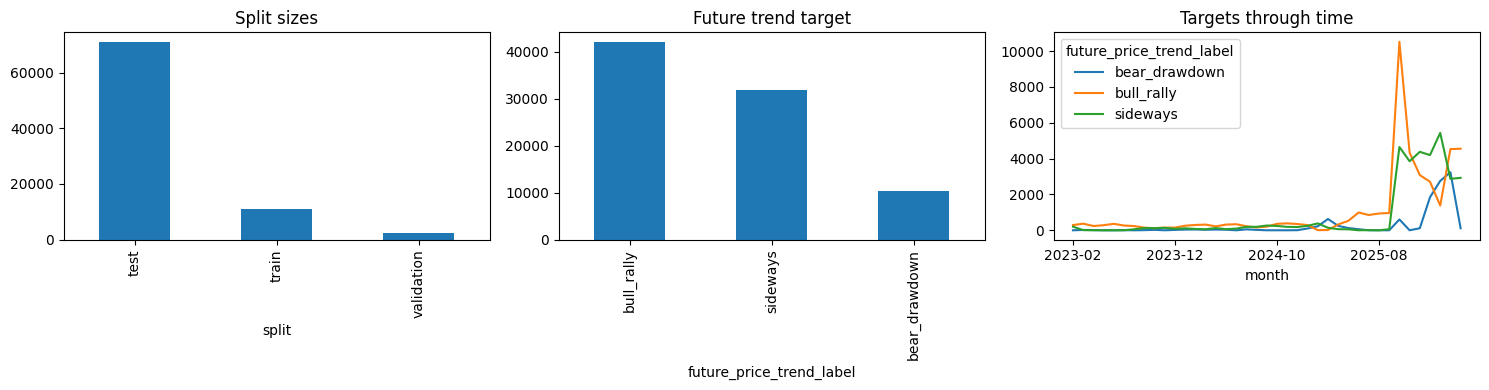

In [4]:
display(df[["ticker","time_published","anchor_trading_date","article_text","relevance_score","price_trend_label","future_price_trend_label","macro_macro_regime"]].head(10))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
df["split"].value_counts().plot(kind="bar", ax=axes[0], title="Split sizes")
df["future_price_trend_label"].value_counts().plot(kind="bar", ax=axes[1], title="Future trend target")
df.groupby(["month", "future_price_trend_label"]).size().unstack(fill_value=0).plot(ax=axes[2], title="Targets through time")
plt.tight_layout()

In [5]:
import hashlib
import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModelForCausalLM

FEATURE_COLUMNS = [c for c in [
    "relevance_score","ticker_sentiment_score","overall_sentiment_score","rally_from_previous_low","drawdown_from_previous_high","price_trend_id","market_sentiment_id","is_relevant","is_market_material","is_material",
    "macro_cpi_yoy","macro_core_cpi_yoy","macro_fed_funds_rate","macro_fed_funds_change_3m","macro_treasury_10y_2y_spread","macro_unemployment_rate","macro_vix","macro_high_inflation","macro_rising_rates","macro_falling_rates","macro_inverted_yield_curve","macro_tightening_regime","macro_easing_regime"
] if c in df.columns]

LABELS = {0:"bear_drawdown", 1:"sideways", 2:"bull_rally"}

def split_df(name, max_rows=None):
    part = df[df.split == name].copy()
    return part.head(max_rows) if max_rows else part

train_df = split_df("train", MAX_TRAIN_ROWS)
val_df = split_df("validation", MAX_VALIDATION_ROWS)
test_df = split_df("test", MAX_TEST_ROWS)

stats = {}
for c in FEATURE_COLUMNS:
    s = pd.to_numeric(train_df[c], errors="coerce")
    stats[c] = (float(s.mean()) if s.notna().any() else 0.0, float(s.std()) if s.notna().any() and s.std() else 1.0)

def features(part):
    arrs=[]
    for c in FEATURE_COLUMNS:
        mean, std = stats[c]
        arrs.append(((pd.to_numeric(part[c], errors="coerce").fillna(mean)-mean)/std).to_numpy(np.float32))
    return np.stack(arrs, axis=1).astype(np.float32)

def targets(part):
    return part["future_price_trend_id"].astype(int).to_numpy()

def show_target_distribution(name, part):
    counts = part["future_price_trend_label"].value_counts().reindex(["bear_drawdown", "sideways", "bull_rally"], fill_value=0)
    pct = (counts / counts.sum() * 100).round(2)
    return pd.DataFrame({"split": name, "count": counts, "percent": pct})

display(pd.concat([
    show_target_distribution("train", train_df),
    show_target_distribution("validation", val_df),
    show_target_distribution("test", test_df),
]))

print("features", len(FEATURE_COLUMNS), FEATURE_COLUMNS)
print("train/val/test", len(train_df), len(val_df), len(test_df))


features 23 ['relevance_score', 'ticker_sentiment_score', 'overall_sentiment_score', 'rally_from_previous_low', 'drawdown_from_previous_high', 'price_trend_id', 'market_sentiment_id', 'is_relevant', 'is_market_material', 'is_material', 'macro_cpi_yoy', 'macro_core_cpi_yoy', 'macro_fed_funds_rate', 'macro_fed_funds_change_3m', 'macro_treasury_10y_2y_spread', 'macro_unemployment_rate', 'macro_vix', 'macro_high_inflation', 'macro_rising_rates', 'macro_falling_rates', 'macro_inverted_yield_curve', 'macro_tightening_regime', 'macro_easing_regime']
train/val/test 10935 2388 70891


In [6]:
class DeepSeekTrendClassifier(nn.Module):
    _shared = {}
    _embedding_cache = {}

    def __init__(self, model_id, structured_dim, dropout=0.1):
        super().__init__()
        self.device_ = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        key = (model_id, str(self.device_))
        if key not in self._shared:
            tokenizer = AutoTokenizer.from_pretrained(model_id, trust_remote_code=True)
            if tokenizer.pad_token is None:
                tokenizer.pad_token = tokenizer.eos_token
            dtype = torch.bfloat16 if self.device_.type == "cuda" else torch.float32
            encoder = AutoModelForCausalLM.from_pretrained(
                model_id,
                trust_remote_code=True,
                torch_dtype=dtype,
                device_map="auto" if self.device_.type == "cuda" else None,
            )
            encoder.eval()
            for p in encoder.parameters():
                p.requires_grad = False
            self._shared[key] = {"tokenizer": tokenizer, "encoder": encoder, "hidden": int(encoder.config.hidden_size)}
        shared = self._shared[key]
        self.tokenizer = shared["tokenizer"]
        self.encoder = shared["encoder"]
        hidden = shared["hidden"]
        self.head = nn.Sequential(nn.Linear(hidden + structured_dim, 512), nn.ReLU(), nn.Dropout(dropout), nn.Linear(512, 3)).to(self.device_)

    @staticmethod
    def _cache_key(text):
        return hashlib.sha1(str(text).encode("utf-8", errors="ignore")).hexdigest()

    def embed_texts(self, texts):
        keys = [self._cache_key(t) for t in texts]
        missing = [(k, t) for k, t in zip(keys, texts) if k not in self._embedding_cache]
        if missing:
            miss_keys, miss_texts = zip(*missing)
            enc = self.tokenizer(list(miss_texts), padding=True, truncation=True, max_length=MAX_LENGTH, return_tensors="pt")
            enc = {k:v.to(self.device_) for k,v in enc.items()}
            with torch.no_grad():
                out = self.encoder(**enc, output_hidden_states=True)
                h = out.hidden_states[-1]
                lengths = enc["attention_mask"].sum(dim=1) - 1
                pooled = h[torch.arange(h.size(0), device=self.device_), lengths].float().detach().cpu()
            for k, emb in zip(miss_keys, pooled):
                self._embedding_cache[k] = emb
        return torch.stack([self._embedding_cache[k] for k in keys]).to(self.device_)

    def logits(self, texts, feats):
        pooled = self.embed_texts(texts)
        feats = torch.as_tensor(feats, dtype=torch.float32, device=self.device_)
        return self.head(torch.cat([pooled, feats], dim=1))

def batches(part, batch_size=BATCH_SIZE, shuffle=False, balanced=False):
    feats, y = features(part), targets(part)
    texts = part["article_text"].fillna("").astype(str).tolist()
    n = len(part)
    if balanced:
        counts = np.bincount(y, minlength=3).astype(np.float64)
        counts[counts == 0] = 1.0
        sample_weights = 1.0 / counts[y]
        sample_probs = sample_weights / sample_weights.sum()
        order = np.random.choice(np.arange(n), size=n, replace=True, p=sample_probs)
    elif shuffle:
        order = np.random.permutation(n)
    else:
        order = np.arange(n)
    for start in range(0, n, batch_size):
        idx = order[start:start+batch_size]
        yield [texts[i] for i in idx], feats[idx], y[idx], part.iloc[idx]

def report(model, part):
    model.head.eval(); preds=[]; ys=[]
    with torch.no_grad():
        for texts, feats, y, _ in batches(part):
            preds.extend(model.logits(texts, feats).argmax(1).cpu().numpy().tolist()); ys.extend(y.tolist())
    pred = np.array(preds); true = np.array(ys)
    acc = float((pred == true).mean())
    rows=[]; f1s=[]
    for i,name in LABELS.items():
        tp = int(((pred==i)&(true==i)).sum()); fp=int(((pred==i)&(true!=i)).sum()); fn=int(((pred!=i)&(true==i)).sum())
        precision = tp/(tp+fp) if tp+fp else 0; recall=tp/(tp+fn) if tp+fn else 0; f1=2*precision*recall/(precision+recall) if precision+recall else 0
        f1s.append(f1)
        rows.append({"label":name,"precision":precision,"recall":recall,"f1":f1,"support":int((true==i).sum())})
    return acc, pd.DataFrame(rows), float(np.mean(f1s))


In [ ]:
def train_baseline():
    model = DeepSeekTrendClassifier(MODEL_ID, len(FEATURE_COLUMNS))
    opt = torch.optim.AdamW(model.head.parameters(), lr=1e-4)
    ce = nn.CrossEntropyLoss()
    best_macro_f1 = -1.0
    best_state = None
    for epoch in range(EPOCHS):
        model.head.train(); losses=[]
        for texts, feats, y, _ in batches(train_df, shuffle=True, balanced=USE_BALANCED_BATCHES):
            opt.zero_grad(); logits = model.logits(texts, feats); target=torch.as_tensor(y, dtype=torch.long, device=model.device_)
            loss = ce(logits, target); loss.backward(); opt.step(); losses.append(float(loss.detach().cpu()))
        acc, per, macro_f1 = report(model, val_df)
        print(f"baseline epoch {epoch+1}: loss={np.mean(losses):.4f}, val_acc={acc:.4f}, val_macro_f1={macro_f1:.4f}")
        display(per)
        if macro_f1 > best_macro_f1:
            best_macro_f1 = macro_f1
            best_state = {k:v.detach().cpu().clone() for k,v in model.head.state_dict().items()}
    if best_state is not None:
        model.head.load_state_dict(best_state)
    return model

baseline_model = train_baseline()
baseline_acc, baseline_per_class, baseline_macro_f1 = report(baseline_model, test_df)
print("Baseline test accuracy", baseline_acc, "macro_f1", baseline_macro_f1)
display(baseline_per_class)


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

/tmp/ipykernel_1004/1064609884.py:10: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:203.)
  opt.zero_grad(); logits = model.logits(texts, feats); target=torch.as_tensor(y, dtype=torch.long, device=model.device_)


baseline epoch 1: loss=1.2407, val_acc=0.1796


,label,precision,recall,f1,support
0,bear_drawdown,0.191130,0.847775,0.311935,427
1,sideways,0.057906,0.226087,0.092199,115
2,bull_rally,0.911111,0.022210,0.043363,1846


...

,label,precision,recall,f1,support
0,bear_drawdown,0.235933,0.559719,0.331944,427
1,sideways,0.053442,0.513043,0.096801,115
2,bull_rally,0.822878,0.120802,0.210675,1846


baseline epoch 4: loss=0.9376, val_acc=0.2144


,label,precision,recall,f1,support
0,bear_drawdown,0.203499,0.817330,0.325864,427
1,sideways,0.063218,0.286957,0.103611,115
2,bull_rally,0.860927,0.070423,0.130195,1846


baseline epoch 5: loss=0.8671, val_acc=0.2190


,label,precision,recall,f1,support
0,bear_drawdown,0.216759,0.733021,0.334580,427
1,sideways,0.058433,0.382609,0.101382,115
2,bull_rally,0.869110,0.089924,0.162985,1846


In [ ]:
import ltn

class LTNConstraintSystem:
    def __init__(self):
        self.And = ltn.Connective(ltn.fuzzy_ops.AndProd())
        self.Or = ltn.Connective(ltn.fuzzy_ops.OrProbSum())
        self.Not = ltn.Connective(ltn.fuzzy_ops.NotStandard())
        self.Implies = ltn.Connective(ltn.fuzzy_ops.ImpliesReichenbach())
        self.Forall = ltn.Quantifier(ltn.fuzzy_ops.AggregPMeanError(), quantifier="f")
        self.SatAgg = ltn.fuzzy_ops.SatAgg(ltn.fuzzy_ops.AggregPMeanError())
        self.Bear = ltn.Predicate(func=lambda x: x[:,0]); self.Sideways = ltn.Predicate(func=lambda x: x[:,1]); self.Bull = ltn.Predicate(func=lambda x: x[:,2])
        self.HighRelevance = ltn.Predicate(func=lambda x: x[:,3].clamp(0,1)); self.LowRelevance = ltn.Predicate(func=lambda x: (1-x[:,3]).clamp(0,1))
        self.Material = ltn.Predicate(func=lambda x: x[:,4].clamp(0,1)); self.HighInflation = ltn.Predicate(func=lambda x: x[:,5].clamp(0,1))
        self.RisingRates = ltn.Predicate(func=lambda x: x[:,6].clamp(0,1)); self.FallingRates = ltn.Predicate(func=lambda x: x[:,7].clamp(0,1))
        self.Tightening = ltn.Predicate(func=lambda x: x[:,8].clamp(0,1)); self.Easing = ltn.Predicate(func=lambda x: x[:,9].clamp(0,1)); self.InvertedCurve = ltn.Predicate(func=lambda x: x[:,10].clamp(0,1))
    def loss(self, logits, batch_df):
        probs = logits.softmax(dim=1)
        def col(name):
            if name in batch_df.columns:
                values = pd.to_numeric(batch_df[name], errors="coerce").fillna(0).to_numpy(np.float32)
            else:
                values = np.zeros(len(batch_df), dtype=np.float32)
            return torch.as_tensor(values, device=logits.device).unsqueeze(1)
        relevance = col("relevance_score").clamp(0,1)
        high_rel = ((relevance-0.25)/0.75).clamp(0,1)
        facts = torch.cat([high_rel, col("is_material"), col("macro_high_inflation"), col("macro_rising_rates"), col("macro_falling_rates"), col("macro_tightening_regime"), col("macro_easing_regime"), col("macro_inverted_yield_curve")], dim=1).clamp(0,1)
        x = ltn.Variable("x", torch.cat([probs, facts], dim=1))
        formulas = [
            self.Forall(x, self.Implies(self.And(self.And(self.Material(x), self.HighRelevance(x)), self.Easing(x)), self.Bull(x))),
            self.Forall(x, self.Implies(self.And(self.And(self.Material(x), self.HighRelevance(x)), self.Tightening(x)), self.Bear(x))),
            self.Forall(x, self.Implies(self.And(self.HighInflation(x), self.RisingRates(x)), self.Not(self.Bull(x)))),
            self.Forall(x, self.Implies(self.And(self.InvertedCurve(x), self.Material(x)), self.Or(self.Bear(x), self.Sideways(x)))),
            self.Forall(x, self.Implies(self.LowRelevance(x), self.Sideways(x))),
            self.Forall(x, self.Implies(self.And(self.FallingRates(x), self.Easing(x)), self.Not(self.Bear(x)))),
        ]
        return 1 - self.SatAgg(*formulas)

def train_ltn(logic_weight=LOGIC_WEIGHT):
    model = DeepSeekTrendClassifier(MODEL_ID, len(FEATURE_COLUMNS)); constraints = LTNConstraintSystem()
    opt = torch.optim.AdamW(model.head.parameters(), lr=1e-4)
    ce = nn.CrossEntropyLoss()
    best_macro_f1 = -1.0
    best_state = None
    for epoch in range(EPOCHS):
        model.head.train(); losses=[]; logic_losses=[]
        for texts, feats, y, part in batches(train_df, shuffle=True, balanced=USE_BALANCED_BATCHES):
            opt.zero_grad(); logits = model.logits(texts, feats); target=torch.as_tensor(y, dtype=torch.long, device=model.device_)
            task_loss = ce(logits, target); logic_loss = constraints.loss(logits, part)
            loss = task_loss + logic_weight * logic_loss; loss.backward(); opt.step()
            losses.append(float(loss.detach().cpu())); logic_losses.append(float(logic_loss.detach().cpu()))
        acc, per, macro_f1 = report(model, val_df)
        print(f"LTN epoch {epoch+1}: loss={np.mean(losses):.4f}, logic={np.mean(logic_losses):.4f}, val_acc={acc:.4f}, val_macro_f1={macro_f1:.4f}")
        display(per)
        if macro_f1 > best_macro_f1:
            best_macro_f1 = macro_f1
            best_state = {k:v.detach().cpu().clone() for k,v in model.head.state_dict().items()}
    if best_state is not None:
        model.head.load_state_dict(best_state)
    return model

ltn_model = train_ltn()
ltn_acc, ltn_per_class, ltn_macro_f1 = report(ltn_model, test_df)
print("LTN test accuracy", ltn_acc, "macro_f1", ltn_macro_f1)
display(ltn_per_class)


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

/tmp/ipykernel_1441/871215321.py:42: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:203.)
  opt.zero_grad(); logits = model.logits(texts, feats); target=torch.as_tensor(y, dtype=torch.long, device=model.device_)


LTN epoch 1: loss=1.3289, logic=0.2443, val_acc=0.3241


,label,precision,recall,f1,support
0,bear_drawdown,0.239130,0.360656,0.287582,427
1,sideways,0.052930,0.486957,0.095482,115
2,bull_rally,0.822157,0.305525,0.445498,1846


...

,label,precision,recall,f1,support
0,bear_drawdown,0.348018,0.185012,0.241590,427
1,sideways,0.052784,0.634783,0.097463,115
2,bull_rally,0.802057,0.338028,0.475610,1846


LTN epoch 3: loss=1.0489, logic=0.2130, val_acc=0.2203


,label,precision,recall,f1,support
0,bear_drawdown,0.221797,0.543326,0.315003,427
1,sideways,0.052930,0.486957,0.095482,115
2,bull_rally,0.838028,0.128927,0.223474,1846


LTN epoch 4: loss=0.9844, logic=0.2151, val_acc=0.1989


,label,precision,recall,f1,support
0,bear_drawdown,0.211171,0.646370,0.318339,427
1,sideways,0.055494,0.434783,0.098425,115
2,bull_rally,0.827778,0.080715,0.147088,1846


In [ ]:
comparison = pd.DataFrame([
    {"model":"DeepSeek baseline", "accuracy":baseline_acc, "macro_f1":baseline_macro_f1, "bear_f1":baseline_per_class.loc[baseline_per_class.label=="bear_drawdown","f1"].iloc[0], "bull_f1":baseline_per_class.loc[baseline_per_class.label=="bull_rally","f1"].iloc[0]},
    {"model":"DeepSeek + LTN", "accuracy":ltn_acc, "macro_f1":ltn_macro_f1, "bear_f1":ltn_per_class.loc[ltn_per_class.label=="bear_drawdown","f1"].iloc[0], "bull_f1":ltn_per_class.loc[ltn_per_class.label=="bull_rally","f1"].iloc[0]},
])
display(comparison)
comparison.set_index("model")[["accuracy","bear_f1","bull_f1"]].plot(kind="bar", figsize=(8,4), title="Out-of-time test performance")
plt.ylim(0,1); plt.tight_layout()


In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import pandas as pd
import numpy as np

def plot_market_regimes(price_df, label_col='price_trend_label', date_col='anchor_trading_date', price_col='anchor_close', ticker_col='ticker'):
    """
    Plots Mag7 stock prices with transparent background bands mapping historical market states.
    """
    # 1. Protect source data and enforce uniform datetimes
    df_clean = price_df.copy()
    df_clean[date_col] = pd.to_datetime(df_clean[date_col])
    
    # 2. Map regime text identifiers exactly to color bands
    state_colors = {
        'bull_rally': '#2ecc71',     # Soft Green
        'bear_drawdown': '#e74c3c',   # Soft Red
        'sideways': '#b2bec3'         # Muted Gray
    }
    
    # 3. Retrieve unique tickers present in the slice
    tickers = sorted(df_clean[ticker_col].unique()) if ticker_col in df_clean.columns else ['Asset']
    
    # Initialize the layout vertical stack
    fig, axes = plt.subplots(len(tickers), 1, figsize=(14, 3.8 * len(tickers)), sharex=True)
    if len(tickers) == 1:
        axes = [axes]
        
    for ax, ticker in zip(axes, tickers):
        # Isolate and clean ticker slice timeline
        if ticker_col in df_clean.columns:
            df_ticker = df_clean[df_clean[ticker_col] == ticker].sort_values(date_col).reset_index(drop=True)
        else:
            df_ticker = df_clean.sort_values(date_col).reset_index(drop=True)
            
        if df_ticker.empty or label_col not in df_ticker.columns:
            ax.text(0.5, 0.5, f"Missing label/data structure for {ticker}", ha='center', va='center', fontsize=12)
            continue
            
        # Draw the underlying stock closing asset value
        ax.plot(df_ticker[date_col], df_ticker[price_col], color='#2d3436', linewidth=2.0, label='Close Price')
        
        # Calculate transition regions to draw optimal contiguous spans
        df_ticker['regime_changed'] = df_ticker[label_col] != df_ticker[label_col].shift(1)
        transition_indices = df_ticker[df_ticker['regime_changed']].index.tolist()
        
        # Fill background regions dynamically based on tracked transitions
        for idx in range(len(transition_indices)):
            start_i = transition_indices[idx]
            end_i = transition_indices[idx+1] - 1 if idx + 1 < len(transition_indices) else df_ticker.index[-1]
            
            state_label = df_ticker.loc[start_i, label_col]
            start_date = df_ticker.loc[start_i, date_col]
            end_date = df_ticker.loc[end_i, date_col]
            
            # Draw overlay if valid state is known
            if pd.notna(state_label) and state_label in state_colors:
                ax.axvspan(start_date, end_date, color=state_colors[state_label], alpha=0.20, lw=0)
                
        # Subplot Layout Details
        ax.set_title(f"Ticker: {ticker}", fontsize=12, fontweight='bold', loc='left', pad=6)
        ax.set_ylabel("Price ($)", fontsize=10)
        ax.grid(True, linestyle='--', alpha=0.4, color='#b2bec3')
        ax.tick_params(axis='both', labelsize=9)

    # Global bottom axis label
    plt.xlabel("Trading Timeline", fontsize=11, fontweight='semibold', labelpad=8)
    
    # Generate unified right-floating Legend panel
    legend_handles = [
        Patch(facecolor=state_colors['bull_rally'], alpha=0.25, label='Bull Rally 🟢'),
        Patch(facecolor=state_colors['bear_drawdown'], alpha=0.25, label='Bear Drawdown 🔴'),
        Patch(facecolor=state_colors['sideways'], alpha=0.25, label='Sideways / Flat ⚪'),
        Line2D([0], [0], color='#2d3436', lw=2.0, label='Stock Close Price')
    ]
    axes[0].legend(handles=legend_handles, loc='upper left', bbox_to_anchor=(1.02, 1.05), borderaxespad=0, frameon=True)
    
    plt.tight_layout()
    return fig

In [ ]:
# Pass the explicit column targets found in your parsed parquets
plot_market_regimes(
    price_df=test_df, 
    label_col='price_trend_label',       # Use 'future_price_trend_label' to check predictions targets instead
    date_col='anchor_trading_date',
    price_col='anchor_close',
    ticker_col='ticker'
)
plt.show()